# Homework 4 

### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 
## Problem 1: Period estimation using Lomb-Scargle periodogram


Below in the notebook is the code that generates Figure 10.17 in the textbook. As it is now, it:
* downloads a dataset of variable stars collected with the [LINEAR](https://en.wikipedia.org/wiki/Lincoln_Near-Earth_Asteroid_Research) telescope,
* selects six of them (as given by the `ids` variable),
* computes the Lomb-Scargle periodogram in the `compute_best_frequencies` function,
* finds the best frequency by looking for the highest peak in the periodiogram, and
* folds the light curves and plots the results.

Either by modifying the code below, or by writing similar code, do the following:

1. Find the frequencies for the first 1000 stars in the LINEAR datasets (i.e., those with IDs in `dataAll.ids[:1000]`, where `dataAll` is the variable containing the LINEAR dataset as defined below).

2. Compute the periods corresponing to the frequencies above, and plot the histogram of periods using 50 bins in range $0 < T < 25$ hours. What do you observe in the histogram?

3. Generate four 6-panel figures analogous to Figure 10.17, for 6 stars (arbitrarily chosen) from the four easily visible peaks, respectivelly. Comment on (dis)similarities of these plots and of stars within each plot.

4. EXTRA CREDIT: compute the histogram in #2 for ALL (about 7000) stars in the data set, not just the first 1000 (note: this will take a while - on a Mac Pro several hours). Modify the histogram range and bin sizes as needed to bring out the features (clusters) in the data. Comment on differences compared to the 1000-star case. Extra credit 20% of this homework! 


### <span style="color:red">WARNING:</span>

For the astroML code below to work properly, you need to install 
numpy version 1.26. For example: conda install "numpy==1.26"



## Problem 2

PCA applied to 4-D data for variable stars from the SDSS and LINEAR surveys:

-- SDSS u-g and g-i colors,

-- LINEAR variability period (logP) and variability amplitude (A).

The code below reads the data and, to get you familar with the dataset, plots the 
g-i vs. u-g and A vs. logP diagrams.

You need to run PCA with four components and then

a) plot P2 vs. P1 diagram, and P3 vs. P1 diagram, and P3 vs. P4 diagram. Comment what insights, if any, did PCA analysis bring.

b) plot P1 vs. g-i and P1 vs. logP diagrams; repeat with P2, P3, and P4. Comment what insights, if any, did PCA analysis bring.

## Problem 3

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does PCA stand for, and what does it do?  

* What does Lomb-Scargle periodogram do?  

# Homework 4: Solutions

### Some useful definitions and functions

In [3]:
import numpy as np 
from matplotlib import pyplot as plt

# monkey-patch before importing the astroML package 
# np.recfromtxt = np.genfromtxt

from astroML.datasets import fetch_LINEAR_geneva
from astroML.decorators import pickle_results
from astroML.time_series import search_frequencies, lomb_scargle, MultiTermFit
from astroML.datasets import fetch_LINEAR_sample
 
%matplotlib inline

### <span style="color:red">CHECK NUMPY VERSION:</span>

It must be 1.26 

In [29]:
print(np.__version__)
print(np.__file__)

1.26.2
d:\sandbox\astr-324-s26-1\.venv\Lib\site-packages\numpy\__init__.py


### Write your solutions below...

## Problem 1

In [30]:
# plot phased light curves 
def plot_lightcurves(df, results, ids):
    #------------------------------------------------------------
    # Plot the phased light-curves
    fig = plt.figure(figsize=(5, 6.5))
    fig.subplots_adjust(hspace=0.1, bottom=0.06, top=0.94, left=0.12, right=0.94)

    for i in range(len(ids)):
        # get the data and best-fit angular frequency
        t, y, dy = df[ids[i]].T
        omega, power = results[ids[i]]
        omega_best = omega[np.argmax(power)]

        # do a fit to the first 4 Fourier components
        mtf = MultiTermFit(omega_best, 4)
        mtf.fit(t, y, dy)
        phase_fit, y_fit, phased_t = mtf.predict(1000, return_phased_times=True)

        # plot the phased data and best-fit curves
        ax = fig.add_subplot(321 + i)
        ax.errorbar(phased_t, y, dy, fmt='.k', ecolor='gray',
                    lw=1, ms=4, capsize=1.5)
        ax.plot(phase_fit, y_fit, '-b', lw=2)

        ax.set_xlim(0, 1)
        ax.set_ylim(plt.ylim()[::-1])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

        ax.text(0.03, 0.04, "ID = %i" % ids[i], ha='left', va='bottom',
                transform=ax.transAxes)
        ax.text(0.03, 0.96, "P = %.2f hr" % (2 * np.pi / omega_best * 24.),
                ha='left', va='top',
                transform=ax.transAxes)

        ylim = ax.get_ylim()
        ax.set_ylim(ylim[0], ylim[0] + 1.1 * (ylim[1] - ylim[0]))

        if i < 4:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        if i % 2 == 0:
            ax.set_ylabel('mag')

        if i in (4, 5):
            ax.set_xlabel('phase')

    return fig

In [31]:
# hack to account for some old numpy code in astroML
def recfromtxt_compat(*args, **kwargs):
    kwargs.setdefault("dtype", None)
    kwargs.setdefault("encoding", None)
    kwargs.setdefault("names", None)
    return np.genfromtxt(*args, **kwargs)

np.recfromtxt = recfromtxt_compat

def compute_best_frequencies(df, ids, n_eval=10000, n_retry=5, generalized=True):
    results = {}
    for i in ids:
        t, y, dy = df[i].T
        kwargs = dict(generalized=generalized)
        # search_frequencies() is a work horse from astroML
        omega, power = search_frequencies(t, y, dy, n_eval=n_eval,
                                          n_retry=n_retry,
                                          LS_kwargs=kwargs)
        # store the power spectrum, power(omega)
        results[i] = [omega, power]

    return results

from astroML.datasets import fetch_LINEAR_sample
dataAll = fetch_LINEAR_sample(data_home="astroML_data")  
# the number of LINEAR stars with light curves
len(dataAll.targets)

7010

In [32]:
my_ids = dataAll.ids[:1000]
results_feq = compute_best_frequencies(dataAll, my_ids, n_eval=10000, n_retry=5)
my_period = []
for i in range(len(my_ids)):
    # get the best-fit angular frequency
    omega, power = results_feq[my_ids[i]]
    omega_best = omega[np.argmax(power)]
    period_best = 2 * np.pi / omega_best * 24
    my_period.append(period_best)
np.size(my_period)

        Use astropy.stats.LombScargle instead. [astroML.time_series.periodogram]
        Use astropy.stats.LombScargle instead. [astroML.time_series.periodogram]


1000

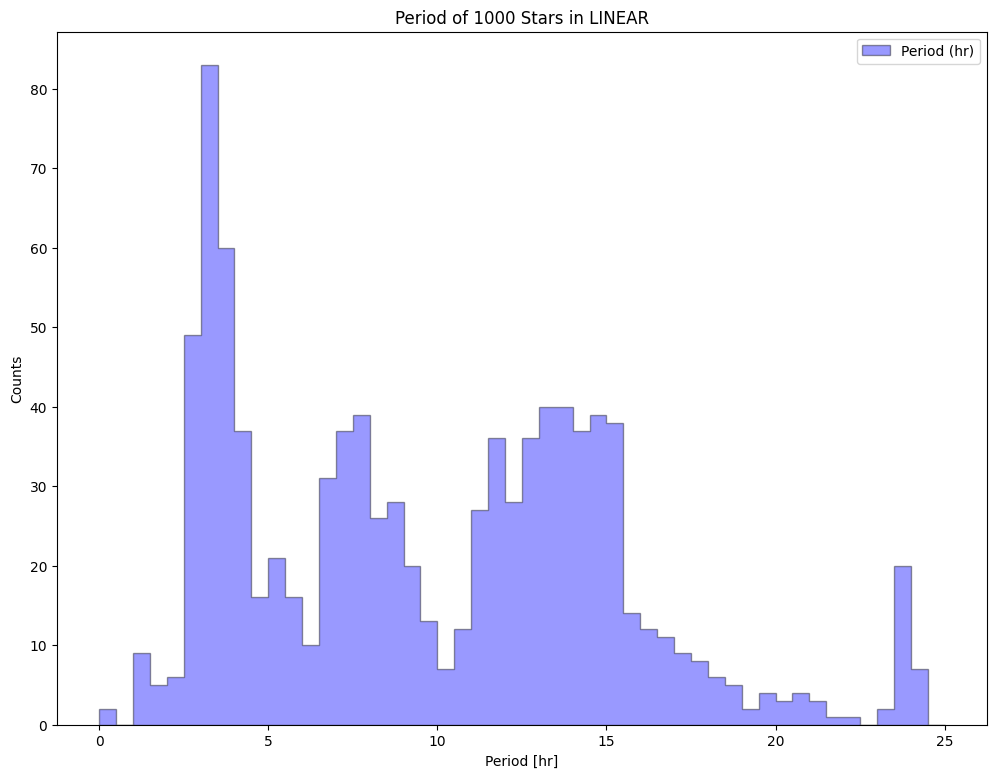

In [33]:
my_bins = np.linspace(0, 25, num=51)

fig, ax = plt.subplots(figsize=(12, 9))

plt.hist(my_period, bins=my_bins, alpha=0.4, color='blue', edgecolor='black', histtype = 'stepfilled', label='Period (hr)')
plt.xlabel('Period [hr]')
plt.ylabel('Counts')
plt.title('Period of 1000 Stars in LINEAR')
plt.legend(loc='upper right')
plt.show();

The histogram has 4 peaks at 3, 7.5, 13 to 14, and 23.5. The peak at 3 is the highest at above 80 counts and peak at 23.5 is the lowest. Peak at 13 to 14 is the widest.

In [34]:
def find_peak_stars(periods, ids, peak_min, peak_max):
    periods_array = np.array(periods)
    ids_array = np.array(ids)
    mask_peak = (periods_array >= peak_min) & (periods_array <= peak_max)
    stars_in_peak = ids_array[mask_peak]
    selected_stars = stars_in_peak[:6]
    return selected_stars

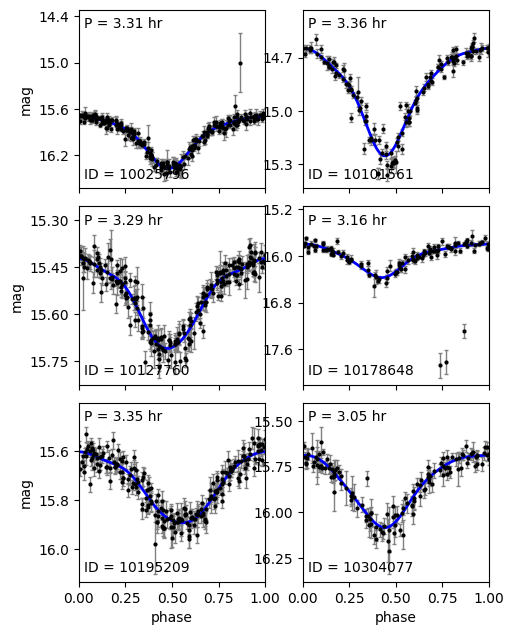

In [35]:
peak1_stars = find_peak_stars(my_period, my_ids, 3.0, 3.5)
peak1plot = plot_lightcurves(dataAll, results_feq, peak1_stars)

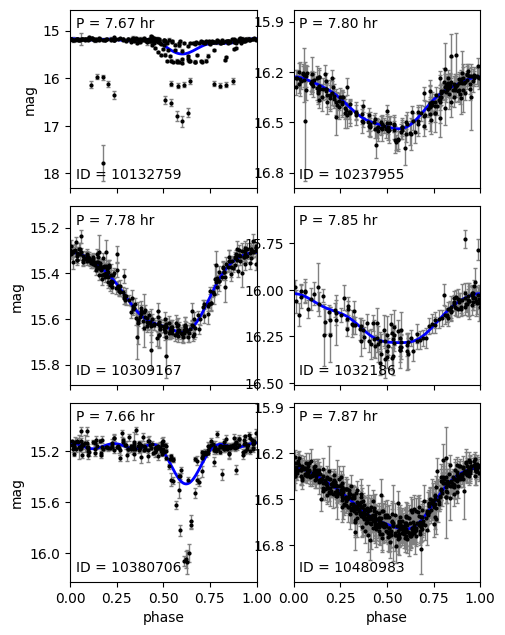

In [36]:
peak2_stars = find_peak_stars(my_period, my_ids, 7.5, 8.0)
peak2plot = plot_lightcurves(dataAll, results_feq, peak2_stars)

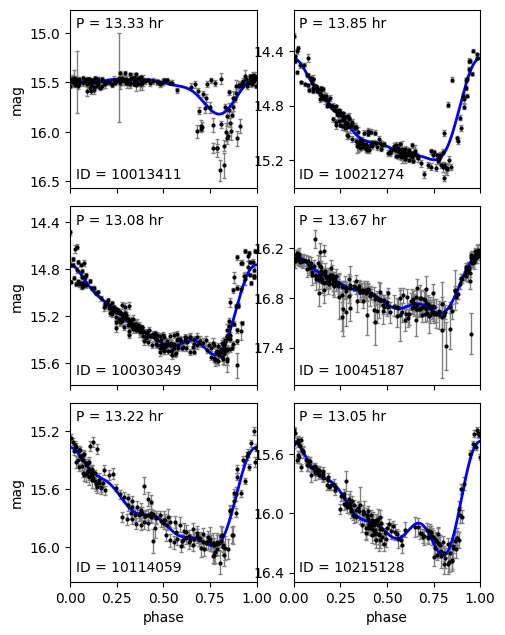

In [37]:
peak3_stars = find_peak_stars(my_period, my_ids, 13.0, 14.0)
peak3plot = plot_lightcurves(dataAll, results_feq, peak3_stars)

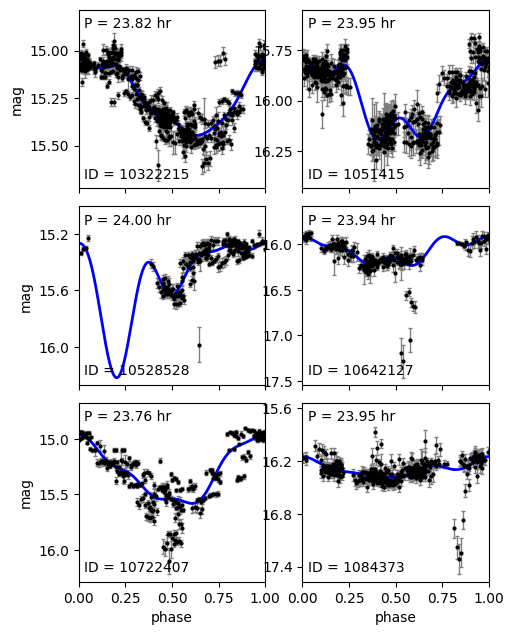

In [38]:
peak4_stars = find_peak_stars(my_period, my_ids, 23.5, 24.0)
peak4plot = plot_lightcurves(dataAll, results_feq, peak4_stars)

Plots 1 and 2 are similar, with the lowest stellar magnitudes occurring at a phase of 0.5 for most stars (all stars in Plot 1 and four stars in Plot 2). Plot 1 appears to have "cleaner" data than Plot 2. Plot 3 is different, as the lowest stellar magnitudes occur at phases of 0.75 or higher. Plot 4 appears much more chaotic than Plot 1, making it difficult to visually determine whether some stars have a clear period.

## Extra

In [39]:
from astroML.plotting import hist

In [40]:
extra_ids = dataAll.ids
extra_feq = compute_best_frequencies(dataAll, extra_ids, n_eval=10000, n_retry=5)
extra_period = []
for i in range(len(extra_ids)):
    # get the best-fit angular frequency
    omega, power = extra_feq[extra_ids[i]]
    omega_best = omega[np.argmax(power)]
    period_best = 2 * np.pi / omega_best * 24
    extra_period.append(period_best)
np.size(extra_period)

7010

        Use astropy.visualization.hist instead. [warnings]


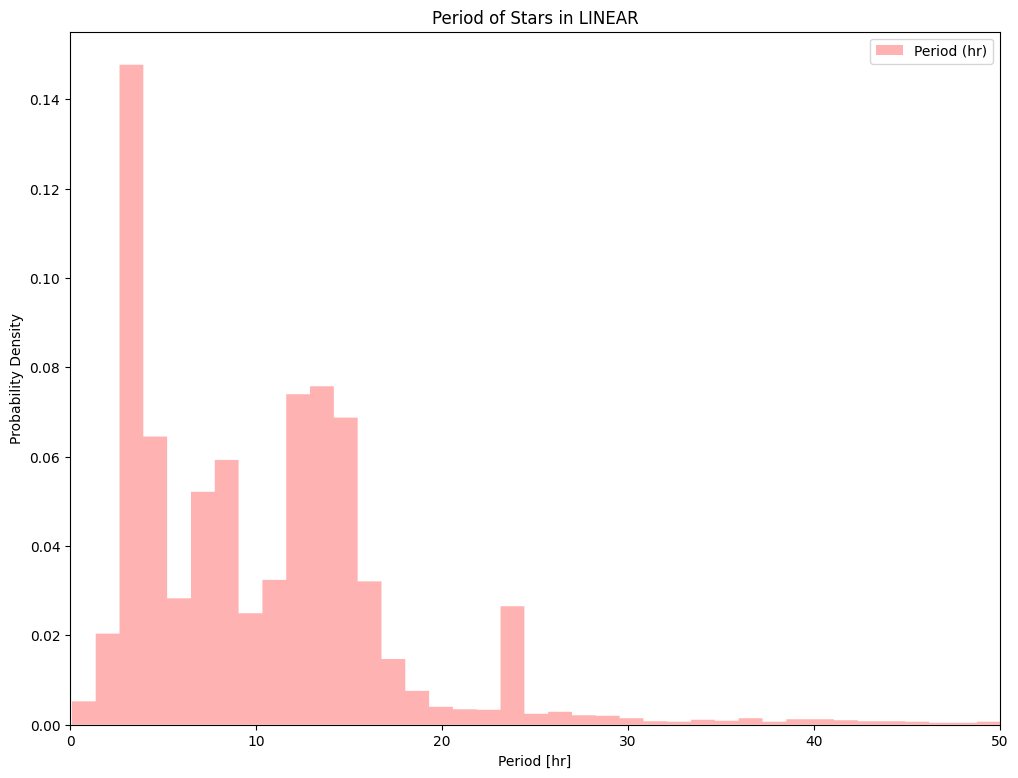

In [69]:
fig, ax = plt.subplots(figsize=(12, 9))

hist(extra_period, bins='knuth', ax=ax, density=True,
    histtype='stepfilled', color='red', alpha=0.3,
    label="Period (hr)")

ax.set_xlim(0, 50)
ax.set_title('Period of Stars in LINEAR')
ax.set_ylabel('Probability Density')
ax.set_xlabel('Period [hr]')
ax.legend(loc='upper right')
plt.show();

The histogram of all stars in the data set looks similar to the 1000 stars one. 4 peaks can be observed at the same period, but the all stars one have a longer tail to the right.

## Problem 2

### First obtain data for 6,146 LINEAR stars with confirmed periodic light curves using an astroML built-in function:

In [5]:
data = fetch_LINEAR_geneva()
# N.B. this is a 7-dimensional dataset, but we use only 4 dimensions
ug = data['ug']
gi = data['gi']
logP = data['logP']
A = data['Ampl']

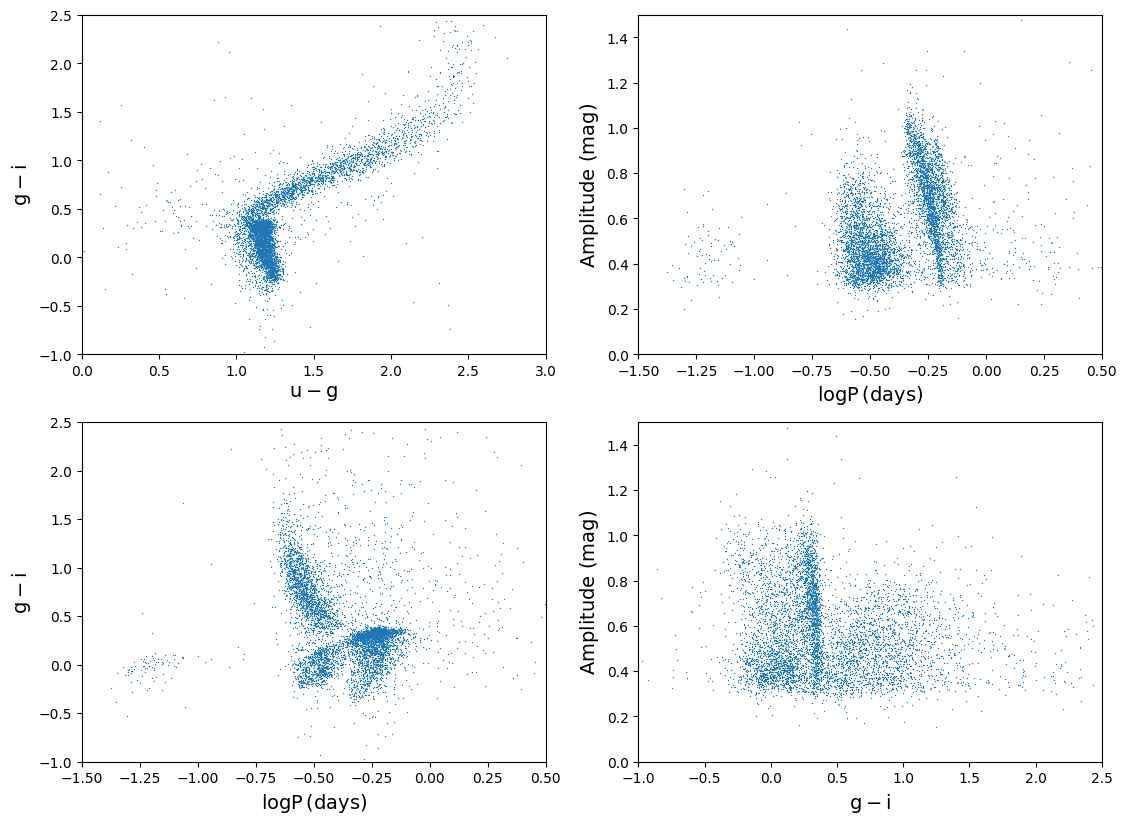

In [6]:
# set up the plot
fig = plt.figure(figsize=(12, 9), facecolor='w')
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.2, bottom=0.1, top=0.93)

# plot the color-color plot
ax1 = fig.add_subplot(221)
ax1.scatter(ug, gi, s=0.9, lw=0)
ax1.set_xlim(0.0, 3.0)
ax1.set_ylim(-1.0, 2.5)
ax1.set_xlabel(r'${\rm u-g}$', color='k', fontsize=14)
ax1.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# plot the A vs. logP plot
ax2 = fig.add_subplot(222)
ax2.scatter(logP, A, s=0.9, lw=0)
ax2.set_xlim(-1.5, 0.5)
ax2.set_ylim(0.0, 1.5)
ax2.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax2.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

# g-i vs. logP
ax3 = fig.add_subplot(223)
ax3.scatter(logP, gi, s=0.9, lw=0)
ax3.set_xlim(-1.5, 0.5)
ax3.set_ylim(-1.0, 2.5)
ax3.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax3.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# A vs. g-i 
ax4 = fig.add_subplot(224)
ax4.scatter(gi, A, s=0.9, lw=0)
ax4.set_xlim(-1.0, 2.5)
ax4.set_ylim(0.0, 1.5)
ax4.set_xlabel(r'${\rm g-i}$', color='k', fontsize=14)
ax4.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

plt.show()

## and now do PCA...

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

my_data = np.column_stack((ug, gi, logP, A))
scaler = StandardScaler()
my_data_scaled = scaler.fit_transform(my_data)
pca = PCA(n_components=4)
my_pca = pca.fit_transform(my_data_scaled)

In [8]:
p1 = my_pca[:, 0]
p2 = my_pca[:, 1]
p3 = my_pca[:, 2]
p4 = my_pca[:, 3]

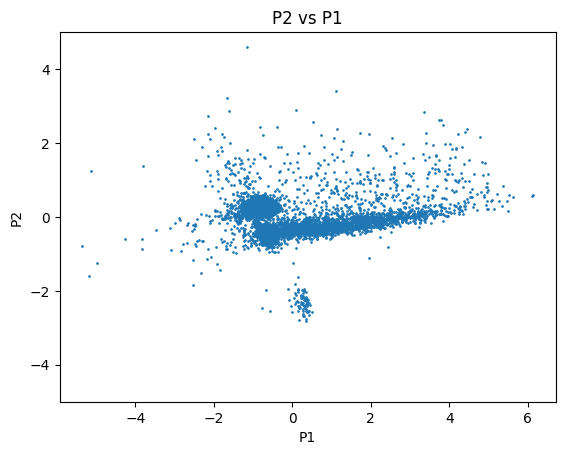

In [9]:
plt.scatter(p1, p2, s=0.9, alpha=1)
plt.xlabel('P1')
plt.ylabel('P2')
plt.title('P2 vs P1')
plt.ylim(-5, 5)
plt.show();

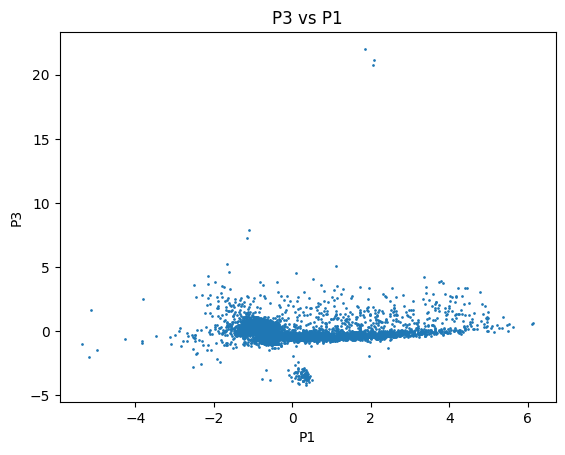

In [81]:
plt.scatter(p1, p3, s=0.9, alpha=1)
plt.xlabel('P1')
plt.ylabel('P3')
plt.title('P3 vs P1')
plt.show();

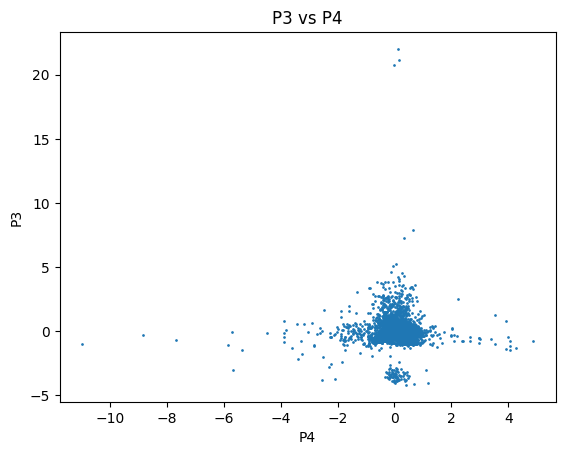

In [82]:
plt.scatter(p4, p3, s=0.9, alpha=1)
plt.xlabel('P4')
plt.ylabel('P3')
plt.title('P3 vs P4')
plt.show();

In the first plot, most points are at 0 on P2 and spread across P1, meaning PCA is successful with P1 being the direction of most variance. In all three plots, there are primarily two clusters, with a larger cluster located above a smaller one. There are also a few outliers (2 to 3) in each plot, around P2 ≈ -40 in Plot 1 and P3 ≈ 20 in Plots 2 and 3. It does appear that the PCA was successful.

In [49]:
def plot_pca(p_number, xlabel):
    # set up the plot
    fig = plt.figure(figsize=(12, 5), facecolor='w')
    fig.suptitle(f'{xlabel} vs. g-i and {xlabel} vs. logP', fontsize=16)

    # P vs. g-i 
    ax1 = fig.add_subplot(121)
    ax1.scatter(gi, p_number, s=0.9, lw=0)
    ax1.set_xlim(-1.0, 2.5)
    ax1.set_xlabel(r'${\rm g-i}$', color='k', fontsize=14)
    ax1.set_ylabel(f'{xlabel}', color='k', fontsize=14)

    # P vs. logP
    ax2 = fig.add_subplot(122)
    ax2.scatter(logP, p_number, s=0.9, lw=0)
    ax2.set_xlim(-1.5, 0.5)
    ax2.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
    ax2.set_ylabel(f'{xlabel}', color='k', fontsize=14)
    
    plt.tight_layout()
    plt.show();

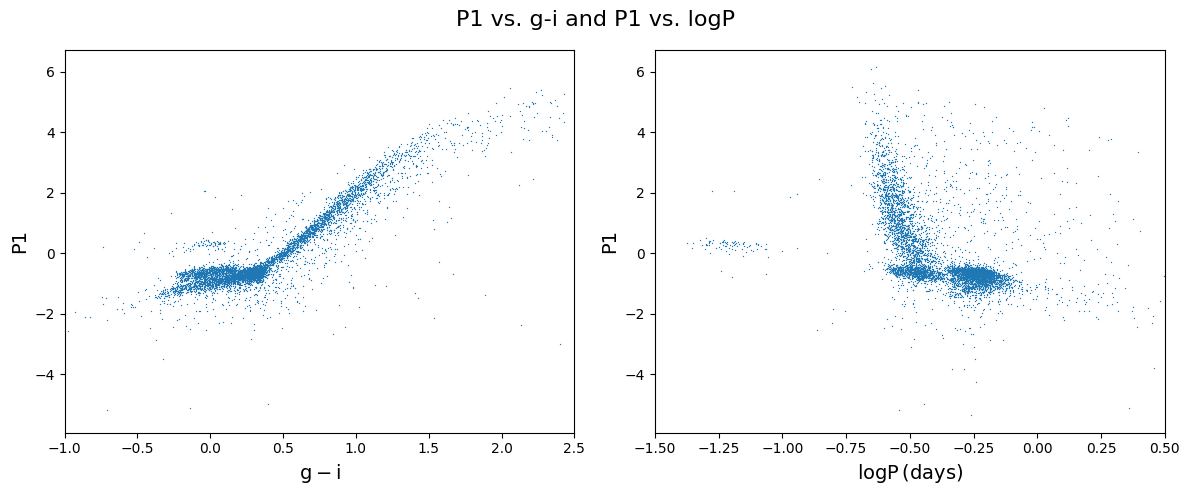

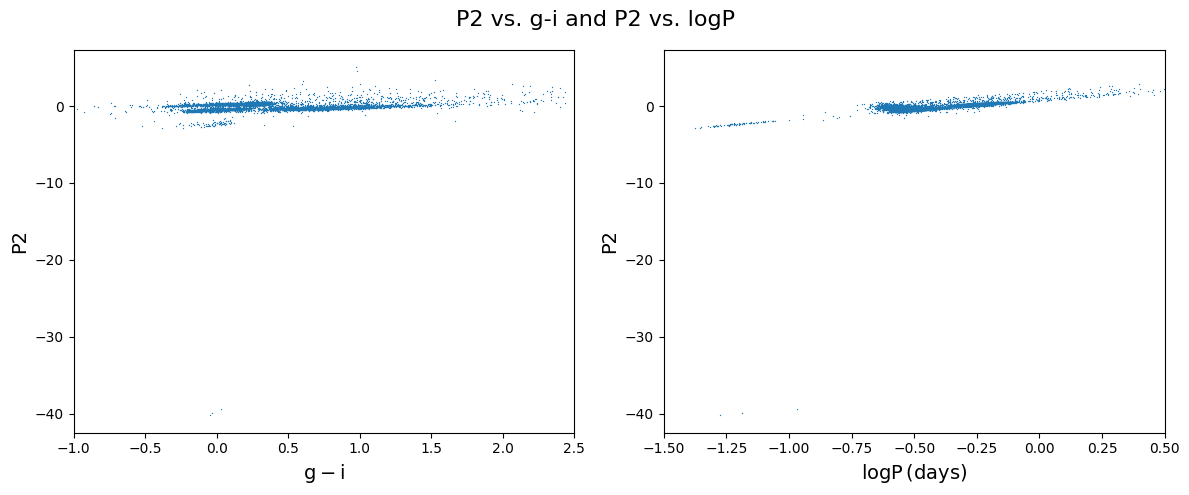

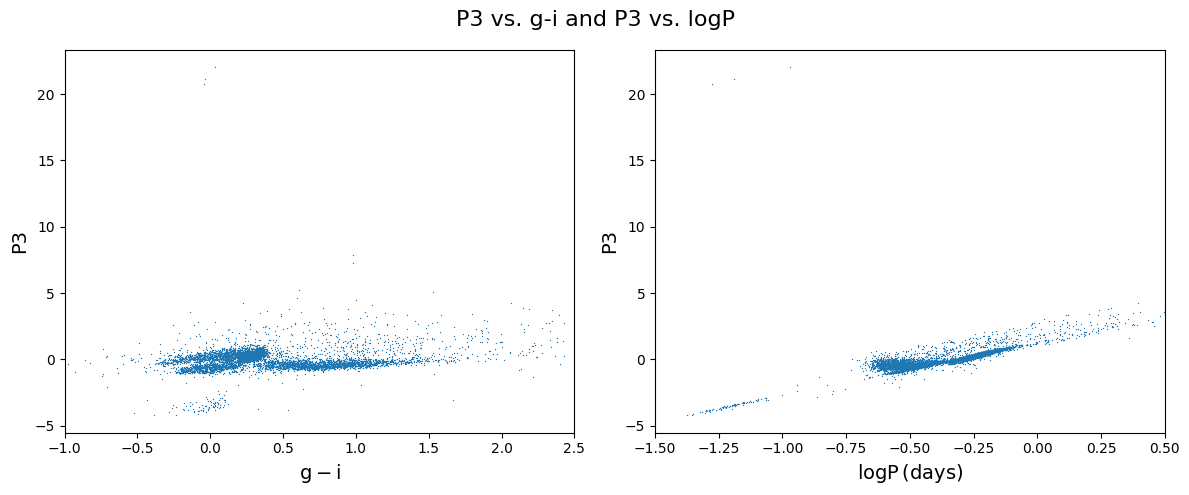

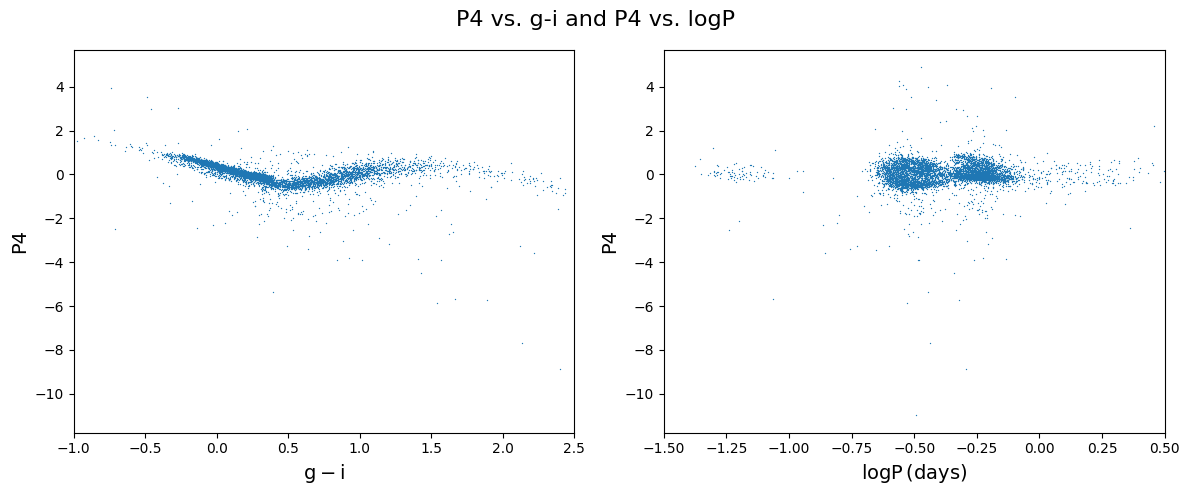

In [50]:
plot_pca(p_number=p1, xlabel='P1')
plot_pca(p_number=p2, xlabel='P2')
plot_pca(p_number=p3, xlabel='P3')
plot_pca(p_number=p4, xlabel='P4')

In the P1 vs. g-i plot, there is a diagonal feature starting around g-i = 0.5, which could indicate that g-i is the strongest differentiator in the sample, as it is correlated with the first principal component. In the P1 vs. logP, P4 vs. logP, and possibly P3 vs. logP plots, two clusters can be observed, suggesting that the PCA successfully separated different types of pulsating stars.

## Problem 3

1. PCA stands for Principal Component Analysis. It reduces the dimensionality of data by finding its eigenvectors and eigenvalues. The first principal component corresponds to the highest eigenvalue (the direction of maximal variance), and the second principal component is orthogonal to the first, capturing the second largest amount of variance. PCA can also be used for spectrum reconstruction.
2. A Lomb-Scargle periodogram plots spectral power versus period. It can be used to determine the best-fit period of a periodic signal by identifying the period that corresponds to the highest power peak.